In [ ]:
from google.colab import files
files.upload()  # upload data.zip
!unzip data.zip

Saving data.zip to data.zip
Archive:  data.zip
   creating: data/
  inflating: data/cattle_symptoms_expanded.xlsx  
   creating: data/images/
   creating: data/images/fmd/
  inflating: data/images/fmd/foot-and-mougth-1-_jpeg.rf.ea8fb57abac2598e495722d36b753119.jpg  
  inflating: data/images/fmd/foot-and-mougth-10-_jpg.rf.bb033ab21e7577799df3936cd53ec5ee.jpg  
  inflating: data/images/fmd/foot-and-mougth-11-_jpg.rf.15be159277669df59120ecc2ae78c5d7.jpg  
  inflating: data/images/fmd/foot-and-mougth-12-_jpg.rf.4e2bbde46b9a4b6c1f74aa202642dc04.jpg  
  inflating: data/images/fmd/foot-and-mougth-13-_jpg.rf.14a93f6b0cef066f5a74c09ce9616095.jpg  
  inflating: data/images/fmd/foot-and-mougth-14-_jpg.rf.e6196689006f7b237a0a1f769707003c.jpg  
  inflating: data/images/fmd/foot-and-mougth-17-_jpg.rf.f5e41cc9ee765e27a3dd87cab4cc89ca.jpg  
  inflating: data/images/fmd/foot-and-mougth-19-_png.rf.4cbacaedc3d7afd68e2035ee4f5724d0.jpg  
  inflating: data/images/fmd/foot-and-mougth-2-_jpg.rf.4539479ca47f6

In [ ]:
!ls data/images


fmd  healthy  lsd


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
blood_df = pd.read_excel("/content/drive/MyDrive/cattle/fbc_reports.xlsx")
symptom_df = pd.read_excel("/content/drive/MyDrive/cattle/symptoms.xlsx")

X_blood = blood_df.drop(columns=["label"])
y = blood_df["label"]

scaler = StandardScaler()
X_blood = scaler.fit_transform(X_blood)

vectorizer = TfidfVectorizer(max_features=200)
X_text = vectorizer.fit_transform(symptom_df["symptoms"]).toarray()

NameError: name 'pd' is not defined

In [ ]:
dataset = datasets.ImageFolder(
    root="data/images",
    transform=transform
)

class_names = dataset.classes
print(class_names)


['fmd', 'healthy', 'lsd']


In [ ]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)


In [ ]:
model = models.vgg16(pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False  # transfer learning


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 197MB/s]


In [ ]:
model.classifier[6] = nn.Linear(4096, 3)
model = model.to(device)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)


In [ ]:
num_epochs = 5
train_acc, val_acc = [], []
train_loss, val_loss = [], []

for epoch in range(num_epochs):
    model.train()
    correct, total, running_loss = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss.append(running_loss / len(train_loader))
    train_acc.append(correct / total)

    # Validation
    model.eval()
    correct, total, running_loss = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss.append(running_loss / len(val_loader))
    val_acc.append(correct / total)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Acc: {train_acc[-1]:.2f} | Val Acc: {val_acc[-1]:.2f}")


Epoch 1/5 | Train Acc: 0.80 | Val Acc: 0.90
Epoch 2/5 | Train Acc: 0.88 | Val Acc: 0.78
Epoch 3/5 | Train Acc: 0.89 | Val Acc: 0.86
Epoch 4/5 | Train Acc: 0.89 | Val Acc: 0.91
Epoch 5/5 | Train Acc: 0.93 | Val Acc: 0.92


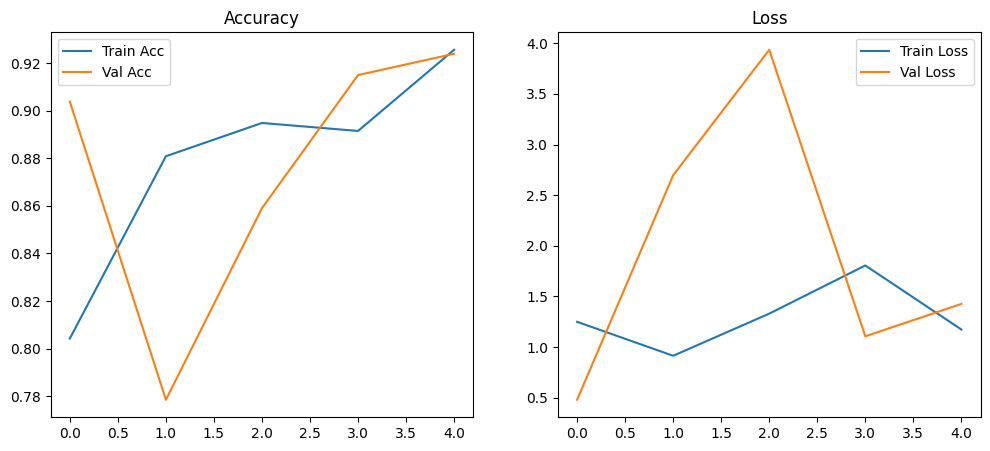

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_acc, label="Train Acc")
plt.plot(val_acc, label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()


In [ ]:
def predict(image_tensor):
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor.to(device))
        _, pred = torch.max(outputs, 1)
        label = class_names[pred.item()]

        if label == "Healthy":
            return "Healthy"
        else:
            return f"Unhealthy → {label}"


In [ ]:
torch.save(model.state_dict(), "cattle_disease_vgg16.pth")


In [ ]:
from google.colab import files
files.download("cattle_disease_vgg16.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install fastapi uvicorn

from fastapi import FastAPI, UploadFile
from PIL import Image
import io

app = FastAPI()

@app.post("/predict")
async def predict_image(file: UploadFile):
    image = Image.open(io.BytesIO(await file.read())).convert("RGB")
    image = transform(image).unsqueeze(0)
    result = predict(image)
    return {"prediction": result}


In [ ]:
def evaluate_model(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return correct / total


In [ ]:
train_accuracy = evaluate_model(model, train_loader)
val_accuracy = evaluate_model(model, val_loader)

print(f"Final Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Final Validation Accuracy: {val_accuracy * 100:.2f}%")


Final Training Accuracy: 97.15%
Final Validation Accuracy: 92.39%
